In [3]:
from google.colab import files
uploaded = files.upload()

Saving tangled_tale.txt to tangled_tale.txt
Saving looking_glass.txt to looking_glass.txt
Saving Alice.txt to Alice.txt


In [8]:
# We start by opening our storybooks (text files).
# We'll read them, clean up the messy parts (like weird symbols), and remove things like the author's notes at the start and end.
# Then we'll save the clean story so we can play with it later.

import re # (short for regular expressions) helps clean messy parts of the text (like punctuation and strange characters).

def load_texts(file_paths):
    corpus = []
    for path in file_paths:
        with open(path, 'r', encoding='utf-8') as f:    # We open the file so Python can read it.'r' means read mode
            text = f.read()

        # Slice to keep only the relevant content between START and END (try to find the beginning and ending of the real story) to avoid credits or legal text at the beginning and end
        start_idx = text.find('*** START')
        end_idx = text.find('*** END')
        if start_idx != -1 and end_idx != -1:  #If both START and END were found, we keep only the part of the book between those points (the real story only)
            text = text[start_idx:end_idx]

        # Clean non-word characters using regex (remove all punctuation and weird characters)
        cleaned_text = re.sub(r'[^\w\s]', ' ', text)  # Keep only words and whitespace (r'[^\w\s]' means: “remove everything except words and spaces”)
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()  # Normalize whitespace (strip() removes any space at the start or end)

        corpus.append(cleaned_text)

    return corpus

In [9]:
file_paths = ['Alice.txt', 'looking_glass.txt', 'tangled_tale.txt']
corpus = load_texts(file_paths) #This runs the load_texts() function using file names and saves the cleaned texts into the variable **corpus**

for i, text in enumerate(corpus):
    print(f"\n Book {i+1} - Preview:\n{text[:200]}")


 Book 1 - Preview:
START OF THE PROJECT GUTENBERG EBOOK ALICE S ADVENTURES IN WONDERLAND Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3 0 Contents CHAPTER I Down the Rabb

 Book 2 - Preview:
START OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKING GLASS Illustration THROUGH THE LOOKING GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition 1 7 DRAMATIS PERSONÆ _A

 Book 3 - Preview:
START OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE Produced by Chris Curnow Carla Foust Lindy Walsh and the Online Distributed Proofreading Team at https www pgdp net Music transcribed by Linda Canto


In [12]:
# breaking stories into little pieces (tokens) — these are just the words.

import nltk
from nltk.tokenize import word_tokenize # breaks the cleaned text into individual words and punctuation

# Downloading NLTK's tokenizer resources
nltk.download('punkt_tab')

# Tokenize each book in the corpus
tokenized_books = [] # saving the list of tokens for each book in tokenized_books

for i, text in enumerate(corpus):
    tokens = word_tokenize(text)
    tokenized_books.append(tokens)
    print(f"\n Book {i+1} - First 150 tokens:\n{tokens[:150]}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



 Book 1 - First 150 tokens:
['START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', 'ALICE', 'S', 'ADVENTURES', 'IN', 'WONDERLAND', 'Illustration', 'Alice', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', '3', '0', 'Contents', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'A', 'Caucus', 'Race', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', 'A', 'Mad', 'Tea', 'Party', 'CHAPTER', 'VIII', 'The', 'Queen', 's', 'Croquet', 'Ground', 'CHAPTER', 'IX', 'The', 'Mock', 'Turtle', 's', 'Story', 'CHAPTER', 'X', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', 'Alice', 's', 'Evidence', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit', 'Hole', 'Alice', 'was', 'beginning',

In [13]:
#  Removing Stopwords: like "I", "me", "the", and "and" since they don't help us understand the story much.
# So we remove these words (stopwords) so we can focus on the important ones.

from nltk.corpus import stopwords

# Download stopwords list
nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from each tokenized book
filtered_books = []

for i, tokens in enumerate(tokenized_books):
    filtered = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]
    filtered_books.append(filtered)

    # Check if some common stopwords were removed
    print(f"\n Book {i+1} - First 50 filtered tokens:\n{filtered[:50]}")
    print("Checking removed words:")
    for word in ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']:
        print(f"'{word}' found: {filtered.count(word)} times")


 Book 1 - First 50 filtered tokens:
['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'ALICE', 'ADVENTURES', 'WONDERLAND', 'Illustration', 'Alice', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'Pool', 'Tears', 'CHAPTER', 'III', 'Caucus', 'Race', 'Long', 'Tale', 'CHAPTER', 'IV', 'Rabbit', 'Sends', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'Pepper', 'CHAPTER', 'VII', 'Mad', 'Tea', 'Party', 'CHAPTER']
Checking removed words:
'i' found: 0 times
'me' found: 0 times
'my' found: 0 times
'myself' found: 0 times
'we' found: 0 times
'our' found: 0 times
'ours' found: 0 times
'ourselves' found: 0 times

 Book 2 - First 50 filtered tokens:
['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'LOOKING', 'GLASS', 'Illustration', 'LOOKING', 'GLASS', 'Alice', 'Found', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'PERSONÆ', 'arranged', 'commencement', 'game', 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
# Stemming with PorterStemmer
# we cut our words down to their roots — like chopping off extra endings from words.
# So "playing", "played", and "plays" will all turn into "play". This helps group similar words together.

from nltk.stem import PorterStemmer

# Initialize the stemmer
stemmer = PorterStemmer()

# Apply stemming to the filtered words (no stopwords)
stemmed_books = []

for i, tokens in enumerate(filtered_books):
    stemmed = [stemmer.stem(word) for word in tokens]
    stemmed_books.append(stemmed)
    print(f"\n Book {i+1} - First 50 stemmed tokens:\n{stemmed[:50]}")



 Book 1 - First 50 stemmed tokens:
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter']

 Book 2 - First 50 stemmed tokens:
['start', 'project', 'gutenberg', 'ebook', 'look', 'glass', 'illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'personæ', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 

In [17]:
# Lemmatization using spaCy (turn words into their proper base forms)
# So "running" becomes "run", "better" becomes "good", and "was" becomes "be".

import spacy  #spaCy looks at the grammar and meaning, not just the letters.

# Load the small English model in spaCy
nlp = spacy.load('en_core_web_sm')

lemmatized_books = []

for i, tokens in enumerate(filtered_books):
    # Join tokens back into a string so spaCy can process them
    doc = nlp(' '.join(tokens))

    # Extract lemmatized forms
    lemmatized = [token.lemma_ for token in doc]
    lemmatized_books.append(lemmatized)

    print(f"\n Book {i+1} - First 50 lemmatized tokens:\n{lemmatized[:50]}")


 Book 1 - First 50 lemmatized tokens:
['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'ALICE', 'ADVENTURES', 'WONDERLAND', 'Illustration', 'Alice', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'content', 'chapter', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'Pool', 'Tears', 'CHAPTER', 'III', 'Caucus', 'Race', 'Long', 'Tale', 'chapter', 'IV', 'Rabbit', 'send', 'Little', 'Bill', 'chapter', 'V', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'Pepper', 'chapter', 'VII', 'mad', 'Tea', 'Party', 'chapter']

 Book 2 - First 50 lemmatized tokens:
['START', 'PROJECT', 'GUTENBERG', 'ebook', 'look', 'GLASS', 'illustration', 'look', 'GLASS', 'Alice', 'find', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'PERSONÆ', 'arrange', 'commencement', 'game', 'WHITE', 'RED', 'PIECES', 'pawns', 'pawn', 'piece', 'Tweedledee', 'Daisy', 'Daisy', 'Humpty', 'Dumpty', 'Unicorn', 'Haigha', 'Messenger', 'Carpenter', 'Sheep', 'Oyster', 'Oyster', 'Walrus', 'W', 'Queen',

In [19]:
# Part-of-Speech (POS) Tagging with NLTK
# puts job labels on each word so we know what kind of word it is (like noun, verb, adjective, etc.)

from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng')


# POS tagging for each book using the filtered (non-stopword) tokens
pos_tagged_books = []

for i, tokens in enumerate(filtered_books):
    pos_tags = pos_tag(tokens)
    pos_tagged_books.append(pos_tags)

    print(f"\n Book {i+1} - First 50 POS-tagged words:")
    print(pos_tags[:50])

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.



 Book 1 - First 50 POS-tagged words:
[('START', 'NNP'), ('PROJECT', 'NNP'), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('ALICE', 'NNP'), ('ADVENTURES', 'NNP'), ('WONDERLAND', 'NNP'), ('Illustration', 'NNP'), ('Alice', 'NNP'), ('Adventures', 'NNP'), ('Wonderland', 'NNP'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('Contents', 'NNP'), ('CHAPTER', 'NNP'), ('Rabbit', 'NNP'), ('Hole', 'NNP'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('Pool', 'NNP'), ('Tears', 'NNP'), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('Caucus', 'NNP'), ('Race', 'NNP'), ('Long', 'NNP'), ('Tale', 'NNP'), ('CHAPTER', 'NNP'), ('IV', 'NNP'), ('Rabbit', 'NNP'), ('Sends', 'NNP'), ('Little', 'NNP'), ('Bill', 'NNP'), ('CHAPTER', 'NNP'), ('V', 'NNP'), ('Advice', 'NNP'), ('Caterpillar', 'NNP'), ('CHAPTER', 'NNP'), ('VI', 'NNP'), ('Pig', 'NNP'), ('Pepper', 'NNP'), ('CHAPTER', 'NNP'), ('VII', 'NNP'), ('Mad', 'NNP'), ('Tea', 'NNP'), ('Party', 'NNP'), ('CHAPTER', 'NNP')]

 Book 2 - Firs

In [27]:
# NN: noun, singular 'desk'
# VB: verb, base form 'take'
# JJ: adjective 'big'
# RB: adverb 'quickly'
# IN: preposition 'of'
# DT: determiner 'the'
# PRP: pronoun 'he'

In [30]:
# Named Entity Recognition (NER)
# finds special names like people, places, countries, or dates (picking out famous characters and places in a fairy tale and putting name tags on them)

import spacy

# Load the small English language model
nlp = spacy.load('en_core_web_sm')

# Named Entity Recognition (NER) for each book
for i, tokens in enumerate(filtered_books):
    # Join the tokens back into one big string so spaCy can understand it as a sentence
    doc = nlp(' '.join(tokens))

    print(f"\n Book {i+1} - Named Entities:")

    # doc.ents gives you all the named entities found by spaCy in the text
    for ent in doc.ents:
        # ent.text → the actual name (like "Alice", "London", "March")
        # ent.label_ → the type of entity (like PERSON, GPE, DATE, etc.)
        print(f"{ent.text} ({ent.label_})")


 Book 1 - Named Entities:
START PROJECT GUTENBERG EBOOK (ORG)
Alice Adventures (PERSON)
Lewis Carroll (PERSON)
Bill CHAPTER V (PERSON)
Croquet Ground CHAPTER (ORG)
Lobster Quadrille CHAPTER (PERSON)
Hole Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
one (CARDINAL)
Alice (PERSON)
four thousand miles (QUANTITY)
Alice (PERSON)
Latitude Longitude (ORG)
Latitude Longitude (PERSON)
Presently (ORG)
Antipathies (ORG)
one (CARDINAL)
Please New Zealand (ORG)
Australia (GPE)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
upon little three (CARDINAL)
Alice (PERSON)
first (ORDINAL)
one (CARDINAL)
second (ORDINAL)
fifteen inches (QUANTITY)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
half (CARDINAL)
Alice (PERSON)
DRINK (ORG)
Drink (PERSON)
Alice (PERSON)
Alice (PERSON)
Alice (PERSON)
ten inches (QUANTITY)
First (ORDINAL)
Alice (PERSON)
Alice (PERSON)
one (CARDINAL)
Alice (PERSON)
two (CARDINAL)
Alice (PERSON)
two (CARDINAL)
EAT (ORG)
Alice (

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


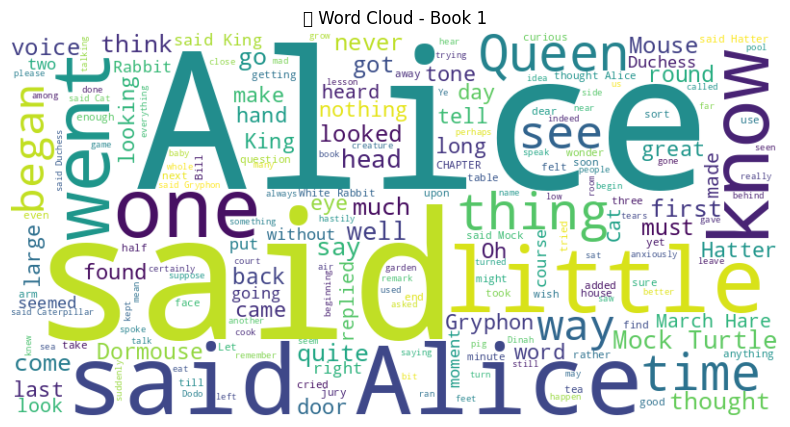

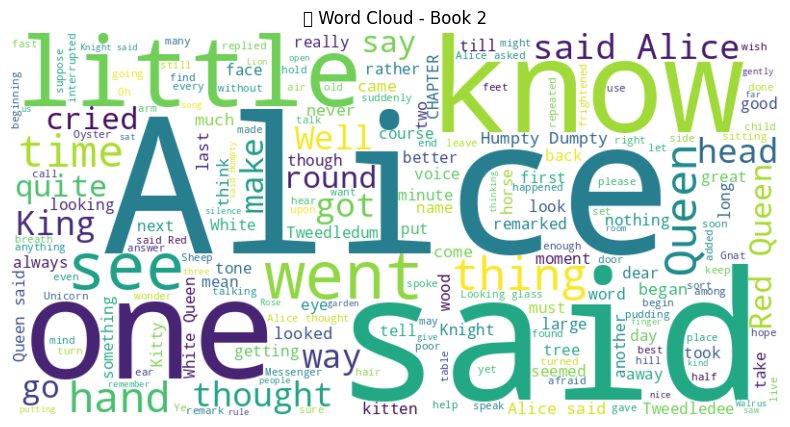

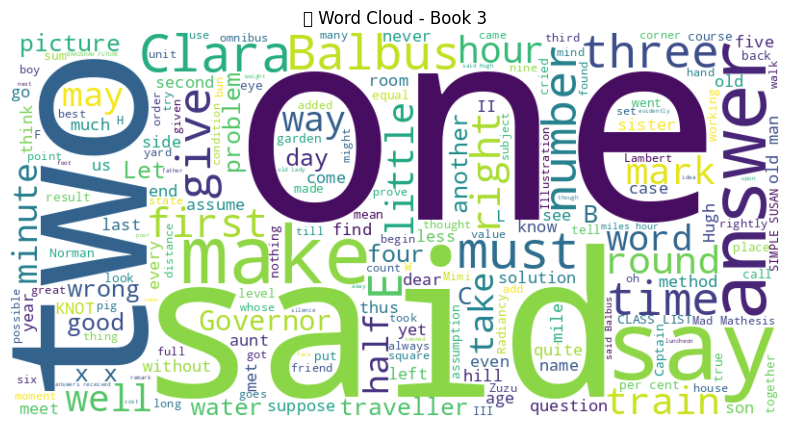

In [31]:
# Word Cloud Visualization (draws a picture made of words)
# The words that appear the most in story will look bigger, and the smaller ones appear less.

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Show word cloud for each book
for i, tokens in enumerate(filtered_books):
    # Join all tokens into one big text string
    text = ' '.join(tokens)

    # Create word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display the word cloud using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Hide axis lines
    plt.title(f"📚 Word Cloud - Book {i+1}")
    plt.show()


In [33]:
# Bag of Words (BoW) Method (counts how often (how many times) each word appears in the book)

# Creating a BoW using CountVectorizer:
from sklearn.feature_extraction.text import CountVectorizer

# Convert the filtered tokens back into full text for each book
cleaned_texts = [' '.join(tokens) for tokens in filtered_books]

# Create the Bag of Words model
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(cleaned_texts)

# Get the vocabulary (the words)
vocab = vectorizer.get_feature_names_out()

# Show top 5 most frequent words in each book
for i in range(len(cleaned_texts)):
    word_counts = X[i].toarray().flatten()

    # Create word-frequency dictionary
    word_freq = dict(zip(vocab, word_counts))

    # Sort by frequency (most to least)
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

    print(f"\n Book {i+1} - Top 5 most frequent words (BoW):")
    for word, count in sorted_words[:5]:
        print(f"{word}: {count}")


 Book 1 - Top 5 most frequent words (BoW):
said: 460
alice: 399
little: 127
one: 101
know: 87

 Book 2 - Top 5 most frequent words (BoW):
said: 473
alice: 468
queen: 189
one: 152
know: 125

 Book 3 - Top 5 most frequent words (BoW):
one: 197
said: 134
two: 102
old: 92
balbus: 70


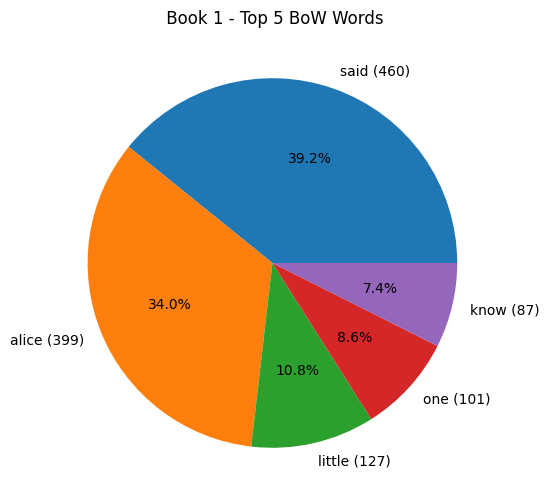

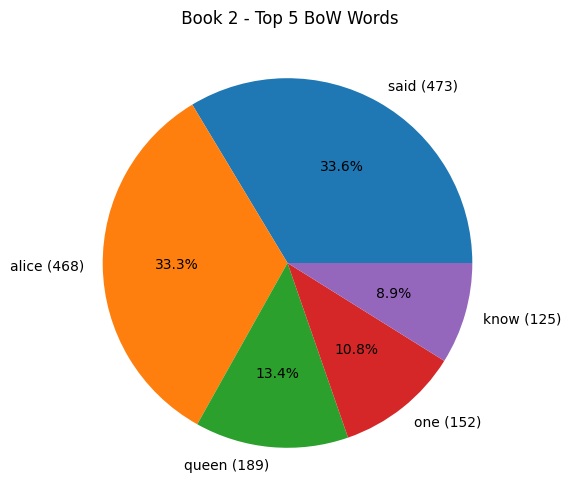

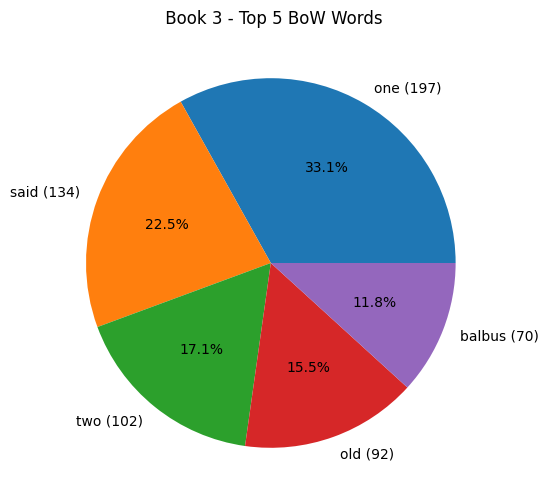

In [35]:
# Pie chart visualization
import matplotlib.pyplot as plt

# Create pie charts for top 5 most frequent words in each book
for i in range(len(cleaned_texts)):
    word_counts = X[i].toarray().flatten()

    # Create a dictionary of word:count
    word_freq = dict(zip(vocab, word_counts))

    # Sort and get top 5 words
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:5]

    words = [item[0] for item in sorted_words]
    counts = [item[1] for item in sorted_words]

    # Create the pie chart
    plt.figure(figsize=(6,6))
    plt.pie(counts, labels=[f"{w} ({c})" for w, c in zip(words, counts)], autopct='%1.1f%%')
    plt.title(f" Book {i+1} - Top 5 BoW Words")
    plt.show()

In [37]:
# TF-IDF: Smarter Word Importance
# Some words like "Alice" or "said" show up a lot, but they’re not special if they appear in every book.
# TF-IDF helps find words that are important in one book but not common in all.

# TF-IDF Victorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF model
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)  # min_df=1 (appear at least once), max_df=2 (appear in max 2 docs)
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_texts)

# Get feature names (words)
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

# Show top 5 most important words by TF-IDF score
for i in range(len(cleaned_texts)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()

    # Create a dictionary of word:tfidf score
    tfidf_dict = dict(zip(tfidf_vocab, tfidf_scores))

    # Sort words by score
    sorted_tfidf = sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:5]

    print(f"\n Book {i+1} - Top 5 most important words (TF-IDF):")
    for word, score in sorted_tfidf:
        print(f"{word}: {score:.4f}")



 Book 1 - Top 5 most important words (TF-IDF):
gryphon: 0.3307
rabbit: 0.3187
turtle: 0.2698
mock: 0.2606
hatter: 0.2561

 Book 2 - Top 5 most important words (TF-IDF):
dumpty: 0.3491
humpty: 0.3491
knight: 0.2848
tweedledum: 0.2285
tweedledee: 0.1777

 Book 3 - Top 5 most important words (TF-IDF):
balbus: 0.3173
clara: 0.2810
answers: 0.1758
marks: 0.1541
governor: 0.1496


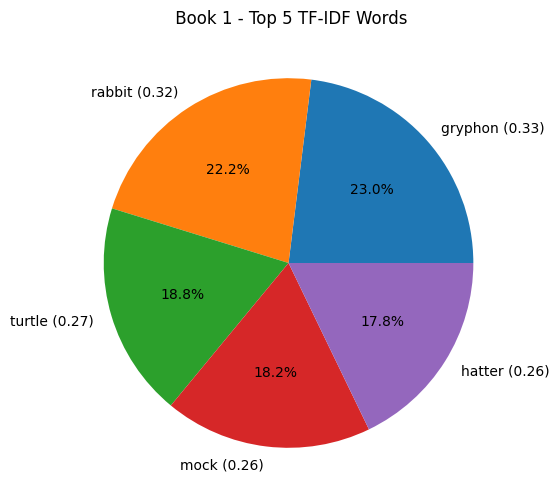

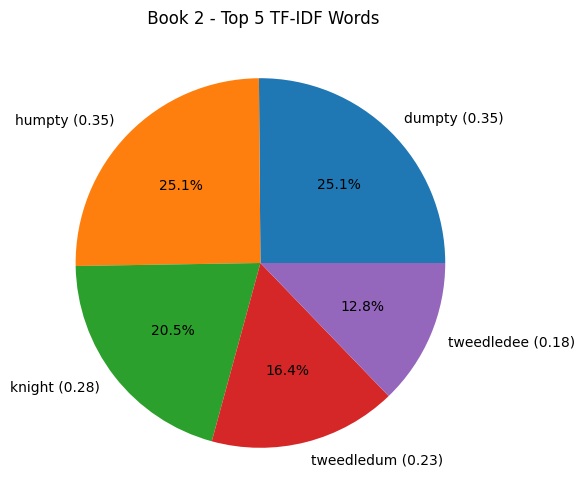

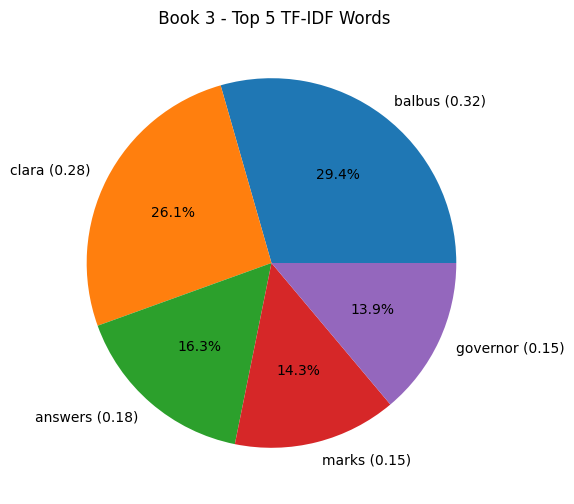

In [38]:
import matplotlib.pyplot as plt

# Create pie charts for top 5 TF-IDF words in each book
for i in range(len(cleaned_texts)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()

    # Create a dictionary of word:score
    tfidf_dict = dict(zip(tfidf_vocab, tfidf_scores))

    # Sort and get top 5 words
    sorted_tfidf = sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:5]

    words = [item[0] for item in sorted_tfidf]
    scores = [item[1] for item in sorted_tfidf]

    # Create the pie chart
    plt.figure(figsize=(6,6))
    plt.pie(scores, labels=[f"{w} ({s:.2f})" for w, s in zip(words, scores)], autopct='%1.1f%%')
    plt.title(f" Book {i+1} - Top 5 TF-IDF Words")
    plt.show()